<a href="https://colab.research.google.com/github/anish00ti/EDA-on-sales/blob/main/Predictive_Ecommerce_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/anish00ti/EDA-on-sales.git

Cloning into 'EDA-on-sales'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 148 (delta 62), reused 44 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 5.57 MiB | 13.47 MiB/s, done.
Resolving deltas: 100% (62/62), done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("EDA-on-sales/data/cleaned/cleaned_sales.csv")

In [4]:
print(df.sample(5))

      Row ID+O6G3A1:R6        order_id  order_date   ship_date  \
5610               206  CA-2020-108329  2020-12-09  2020-12-14   
4853               424  CA-2020-125388  2020-10-19  2020-10-23   
3584              4820  CA-2020-117436  2020-06-08  2020-06-14   
4009              2186  CA-2020-124576  2020-08-01  2020-08-04   
4819              5698  CA-2020-126123  2020-10-14  2020-10-18   

           ship_mode customer_id      customer_name      segment  \
5610  Standard Class    LE-16810    Laurel Elliston     Consumer   
4853  Standard Class    MP-17965      Michael Paige    Corporate   
3584  Standard Class    LW-17125     Liz Willingham     Consumer   
4009    Second Class    HK-14890   Heather Kirkland    Corporate   
4819  Standard Class    AG-10765  Anthony Garverick  Home Office   

            country      city          state   region       product_id  \
5610  United States  Whittier     California     West  TEC-PH-10001918   
4853  United States  Lawrence  Massachusetts  

In [5]:
print(f"given data has {df.shape[0]} rows and {df.shape[1]}columns")

given data has 5901 rows and 20columns


In [6]:
df.dtypes

,0
Row ID+O6G3A1:R6,int64
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_id,object
customer_name,object
segment,object
country,object
city,object


In [7]:
df.columns

Index(['Row ID+O6G3A1:R6', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'region', 'product_id', 'category', 'sub_category', 'product_name',
       'sales', 'quantity', 'profit', 'payment_mode'],
      dtype='object')

In [8]:
df['order_date']=pd.to_datetime(df["order_date"], format="mixed" , errors="coerce")
df['ship_date']=pd.to_datetime(df["ship_date"], format="mixed" , errors="coerce")


In [9]:
df['year']=df['order_date'].dt.year
df['month']=df['order_date'].dt.month

In [10]:
df['month']=df['month'].map({1:"Jan",2:"Feb" ,3:"Mar",4:"Apr",5:"May",6:"jun",7:"jul",8:"Aug",9:"sep",
10:"Oct",11:"Nov",12:"Dec"})

In [11]:
for col in df.columns:
  if df[col].nunique() < 10:
    df[col]=df[col].astype("category")

In [12]:
print(df.sample(2))

      Row ID+O6G3A1:R6        order_id order_date  ship_date       ship_mode  \
5343              2593  CA-2020-128300 2020-11-24 2020-11-26    Second Class   
4081              6071  CA-2020-167542 2020-08-13 2020-08-20  Standard Class   

     customer_id   customer_name    segment        country          city  ...  \
5343    RS-19765  Roland Schwarz  Corporate  United States   Summerville  ...   
4081    KD-16495   Keith Dawkins  Corporate  United States  Philadelphia  ...   

           product_id         category sub_category  \
5343  TEC-PH-10002807       Technology       Phones   
4081  OFF-LA-10004093  Office Supplies       Labels   

                                   product_name    sales quantity   profit  \
5343  Motorla HX550 Universal Bluetooth Headset  114.100        2  39.5500   
4081                                  Avery 486  129.544        3   5.9211   

      payment_mode  year month  
5343           COD  2020   Nov  
4081           COD  2020   Aug  

[2 rows x 22 c

In [13]:
cols=[""]

In [14]:
df.isnull().sum()

,0
Row ID+O6G3A1:R6,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
segment,0
country,0
city,0


In [15]:
print(f"Number of duplicated rows based on 'order_id': {df.duplicated(subset=['order_id']).sum()}")
display(df[df.duplicated(subset=['order_id'])].head(20))

Number of duplicated rows based on 'order_id': 2898


,Row ID+O6G3A1:R6,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,profit,payment_mode,year,month
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.940,3,38.2668,Online,2019,Jan
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.980,2,67.2742,Cards,2019,Jan
5,8605,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,TEC-AC-10002942,Technology,Accessories,WD My Passport Ultra 1TB Portable External Har...,165.600,3,-6.2100,Online,2019,Jan
6,8606,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,TEC-PH-10002890,Technology,Phones,AT&T 17929 Lendline Telephone,180.960,5,13.5720,Cards,2019,Jan
8,9495,CA-2019-105207,2019-01-03,2019-01-08,Standard Class,BO-11350,Bill Overfelt,Corporate,United States,Broken Arrow,...,OFF-BI-10004364,Office Supplies,Binders,Storex Dura Pro Binders,11.880,2,5.3460,COD,2019,Jan
11,5869,CA-2019-158211,2019-01-04,2019-01-08,Standard Class,BP-11185,Ben Peterman,Corporate,United States,Philadelphia,...,OFF-BI-10002026,Office Supplies,Binders,Avery Arch Ring Binders,104.580,6,-80.1780,Online,2019,Jan
13,864,CA-2019-134474,2019-01-05,2019-01-07,Second Class,AJ-10795,Anthony Johnson,Corporate,United States,Jacksonville,...,OFF-AR-10003958,Office Supplies,Art,Newell 337,5.248,2,0.5904,Online,2019,Jan
14,865,CA-2019-134474,2019-01-05,2019-01-07,Second Class,AJ-10795,Anthony Johnson,Corporate,United States,Jacksonville,...,TEC-PH-10002923,Technology,Phones,Logitech B530 USB Headset - headset - Full siz...,59.184,2,5.1786,COD,2019,Jan
17,8032,CA-2019-158806,2019-01-07,2019-01-11,Standard Class,NM-18520,Neoma Murray,Consumer,United States,Amarillo,...,OFF-PA-10004621,Office Supplies,Paper,Xerox 212,25.920,5,9.0720,Cards,2019,Jan
19,6852,US-2019-100461,2019-01-08,2019-01-12,Standard Class,JO-15145,Jack O'Briant,Corporate,United States,Franklin,...,OFF-BI-10001460,Office Supplies,Binders,Plastic Binding Combs,106.050,7,49.8435,Cards,2019,Jan


In [16]:
# Remove duplicated rows based on all columns, keeping the last occurrence
df.drop_duplicates( subset=['order_id'],keep='last', inplace=True)
print(f"DataFrame shape after dropping duplicates: {df.shape}")

DataFrame shape after dropping duplicates: (3003, 22)


In [17]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")
display(df[df.duplicated()].head(10))

Number of duplicated rows: 0


,Row ID+O6G3A1:R6,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,profit,payment_mode,year,month


In [18]:
df.columns

Index(['Row ID+O6G3A1:R6', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'region', 'product_id', 'category', 'sub_category', 'product_name',
       'sales', 'quantity', 'profit', 'payment_mode', 'year', 'month'],
      dtype='object')

In [19]:
for col in df.columns:
  unique_value=df[col].nunique()
  print(f"the column ---{col}--- has --{unique_value}--- unique values and is --{df[col].dtypes}")

the column ---Row ID+O6G3A1:R6--- has --3003--- unique values and is --int64
the column ---order_id--- has --3003--- unique values and is --object
the column ---order_date--- has --642--- unique values and is --datetime64[ns]
the column ---ship_date--- has --690--- unique values and is --datetime64[ns]
the column ---ship_mode--- has --4--- unique values and is --category
the column ---customer_id--- has --773--- unique values and is --object
the column ---customer_name--- has --773--- unique values and is --object
the column ---segment--- has --3--- unique values and is --category
the column ---country--- has --1--- unique values and is --category
the column ---city--- has --452--- unique values and is --object
the column ---state--- has --49--- unique values and is --object
the column ---region--- has --4--- unique values and is --category
the column ---product_id--- has --1446--- unique values and is --object
the column ---category--- has --3--- unique values and is --category
the co

In [20]:
df.drop(columns="Row ID+O6G3A1:R6", inplace=True)

In [21]:
def analyze_high_cardinality_object_columns(df):

    print("\n--- Analyzing High Cardinality Object Columns ---")
    for col in df.columns:
        if df[col].dtypes == 'object' and df[col].nunique() >=773 :
            print(f"\nColumn: '{col}' (High Cardinality Object Type)")
            print(df[col].value_counts().head(5))
    print("---------------------------------------------------")

In [22]:

analyze_high_cardinality_object_columns(df)


--- Analyzing High Cardinality Object Columns ---

Column: 'order_id' (High Cardinality Object Type)
order_id
CA-2020-151450    1
CA-2019-160304    1
CA-2019-125206    1
US-2019-116365    1
CA-2019-105207    1
Name: count, dtype: int64

Column: 'customer_id' (High Cardinality Object Type)
customer_id
EP-13915    14
PK-19075    11
SH-19975    11
SJ-20125    11
RB-19465    10
Name: count, dtype: int64

Column: 'customer_name' (High Cardinality Object Type)
customer_name
Emily Phan       14
Pete Kriz        11
Sally Hughsby    11
Sanjit Jacobs    11
Rick Bensley     10
Name: count, dtype: int64

Column: 'product_id' (High Cardinality Object Type)
product_id
OFF-BI-10000301    8
OFF-BI-10001524    8
OFF-BI-10004236    7
OFF-BI-10004654    7
TEC-AC-10003832    7
Name: count, dtype: int64

Column: 'product_name' (High Cardinality Object Type)
product_name
Easy-staple paper          17
Staple envelope            13
Staples                    13
Staples in misc. colors     9
GBC Instant Repor

In [23]:
def columns(df):
  for col in df.columns:
    number_of_unique_value=df[col].nunique()
    print(f"we have coumn name  [-{col}-] is of [-{df[col].dtype}-] and has unique value[-{number_of_unique_value}-]")


In [24]:
columns(df)

we have coumn name  [-order_id-] is of [-object-] and has unique value[-3003-]
we have coumn name  [-order_date-] is of [-datetime64[ns]-] and has unique value[-642-]
we have coumn name  [-ship_date-] is of [-datetime64[ns]-] and has unique value[-690-]
we have coumn name  [-ship_mode-] is of [-category-] and has unique value[-4-]
we have coumn name  [-customer_id-] is of [-object-] and has unique value[-773-]
we have coumn name  [-customer_name-] is of [-object-] and has unique value[-773-]
we have coumn name  [-segment-] is of [-category-] and has unique value[-3-]
we have coumn name  [-country-] is of [-category-] and has unique value[-1-]
we have coumn name  [-city-] is of [-object-] and has unique value[-452-]
we have coumn name  [-state-] is of [-object-] and has unique value[-49-]
we have coumn name  [-region-] is of [-category-] and has unique value[-4-]
we have coumn name  [-product_id-] is of [-object-] and has unique value[-1446-]
we have coumn name  [-category-] is of [-cat

## Column Categorization

**Numerical Columns**
sales
quantity
profit

**Time Columns**
order_date
ship_date
month
year

**Customer Columns**
customer_id
customer_name
segment

**Product Columns**
category
sub_category
product_name

**Geographic Columns**
city
state
region

**Shipping Columns**
ship_mode

**date validation**

In [25]:
df[['order_date','ship_date']].describe()

,order_date,ship_date
count,3003,3003
mean,2020-02-29 22:25:32.067932160,2020-03-04 20:52:30.449550336
min,2019-01-02 00:00:00,2019-01-05 00:00:00
25%,2019-09-13 12:00:00,2019-09-18 00:00:00
50%,2020-03-19 00:00:00,2020-03-23 00:00:00
75%,2020-09-14 00:00:00,2020-09-17 00:00:00
max,2020-12-31 00:00:00,2021-01-05 00:00:00


The date validation shows that order_date ranges from 2019-01-02 to 2020-12-31, and ship_date ranges from 2019-01-05 to 2021-01-05. On average, items are shipped about 3 to 4 days after the order is placed.


**Stage 3: Univariate Analysis**

In [26]:
def do_univariate_analysis_for_numerical(x):
  print(f"mean of {x.name} is {x.mean()}")
  print(f"minimum value  of {x.name} is {x.min()}")
  print(f"maximum value of  {x.name} is {x.max()}")
  print(f"standard deviation of {x.name} is {x.std()}")
  print(f"median of {x.name} is {x.median()}")
  sk=x.skew()
  if sk ==0:
    print(f"hence skewness is {sk} so it is not skewed normal")
  elif sk >0:
    print(f"hence skewness is {sk} so it is right skew")
  else:
      print(f"hence skewness is {sk} so it is left skew ")

  print("this is histogram")
  plt.figure(figsize=(8, 5)) # Create a new figure for the histogram
  sns.histplot(x , bins=20 ,kde=True , color='blue')
  plt.title(f'Histogram of {x.name}')
  plt.show() # Display the histogram

  print("and this is box plot")
  plt.figure(figsize=(8, 5)) # Create a new figure for the box plot
  sns.boxplot(x)
  plt.title(f'Box Plot of {x.name}')
  plt.show() # Display the boxplot

mean of sales is 241.35946806526806
minimum value  of sales is 0.836
maximum value of  sales is 5517.97
standard deviation of sales is 434.04433551364525
median of sales is 128.4
hence skewness is 5.774177276812975 so it is right skew
this is histogram


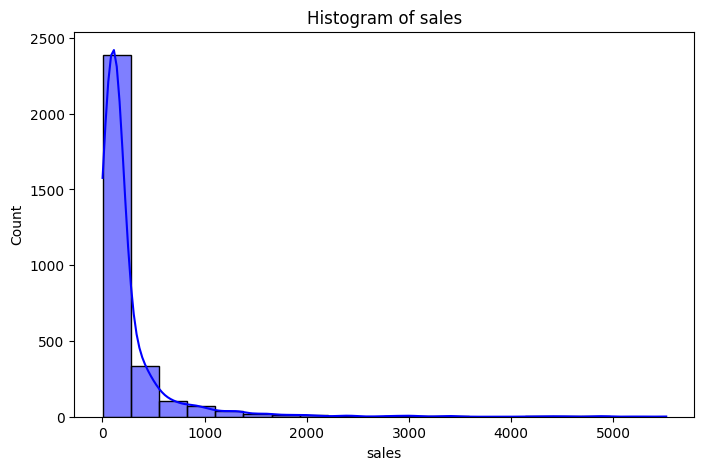

and this is box plot


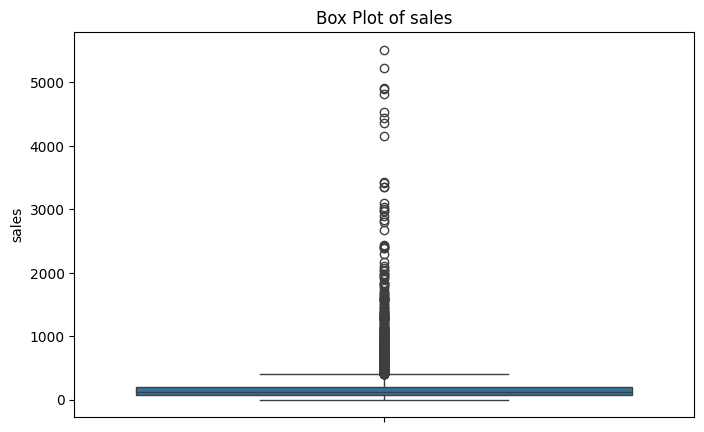

In [27]:
do_univariate_analysis_for_numerical(df['sales'])

Business Insight: This distribution suggests that while many transactions generate modest revenue, a substantial portion of overall sales value comes from a small number of high-value deals. Businesses could focus on strategies to increase the frequency of these high-value sales or upsell/cross-sell to existing customers to boost overall revenue.

mean of profit is 25.26084375624375
minimum value  of profit is -3839.9904
maximum value of  profit is 5039.9856
standard deviation of profit is 205.58962720972028
median of profit is 7.986
hence skewness is 7.258115055758343 so it is right skew
this is histogram


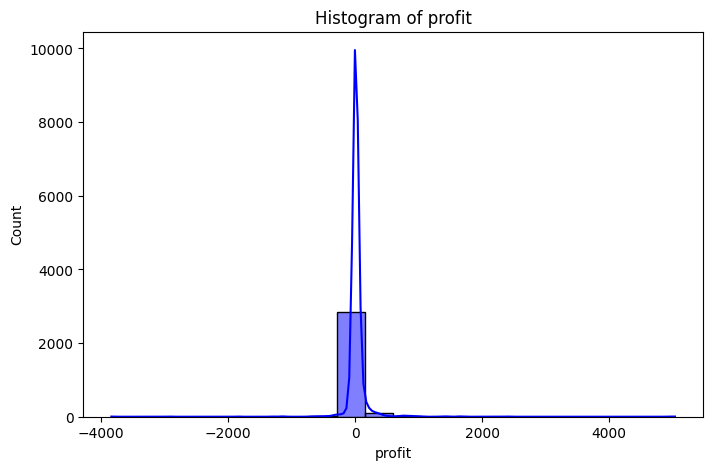

and this is box plot


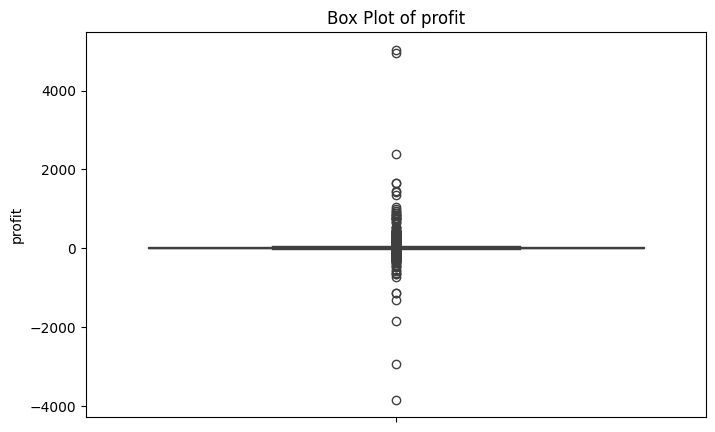

In [28]:
do_univariate_analysis_for_numerical(df['profit'])

Profit is highly volatile, with an average of 25.26 skewed by a few high gains, while most transactions yield low or negative profit
median  25.26 skewed by a few high gains, while most transactions yield low or negative profit median $7.99

Business Insight: Focus on reducing losses and replicating factors from highly profitable sales

mean of quantity is 3.7722277722277724
minimum value  of quantity is 1
maximum value of  quantity is 14
standard deviation of quantity is 2.231310997199565
median of quantity is 3.0
hence skewness is 1.2033478389589614 so it is right skew
this is histogram


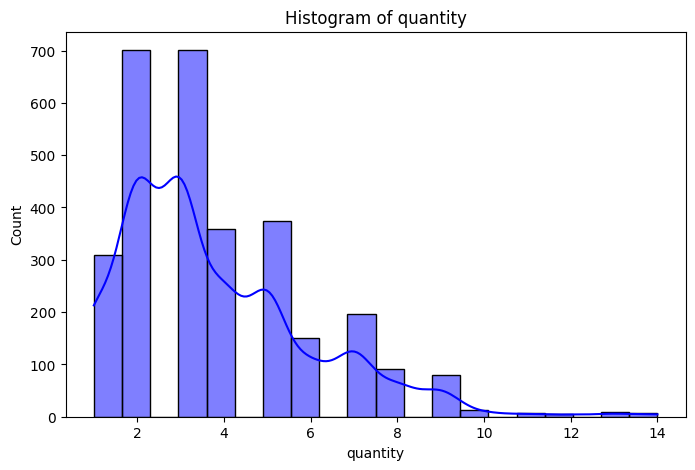

and this is box plot


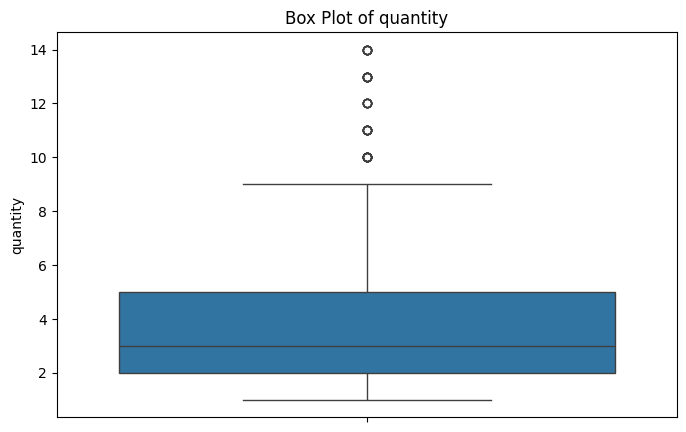

In [29]:
do_univariate_analysis_for_numerical(df['quantity'])

ost orders are small, but a few are large.

Business Insight: Encourage more bulk purchases and increase frequency of small orders.


In [30]:
def show_univariate_analysis_for_categorical(x):
  print(f"{x.name} has {x.nunique()} unique categories.")
  print("\nTop 5 most frequent categories:")
  print(x.value_counts().head(5))
  print(f"\nMost common category is: {x.mode().iloc[0]}")
  print(f"Least common category is: {x.value_counts().sort_values(ascending=True).index[0]}")
  print("and this is count plot")
  plt.figure(figsize=(8, 5)) # Create a new figure for the box plot
  sns.countplot(x=x ,palette='viridis')
  plt.title(f'count Plot of {x.name}')
  plt.show()



segment has 3 unique categories.

Top 5 most frequent categories:
segment
Consumer       1528
Corporate       915
Home Office     560
Name: count, dtype: int64

Most common category is: Consumer
Least common category is: Home Office
and this is count plot


/tmp/ipykernel_7310/1516179385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x ,palette='viridis')


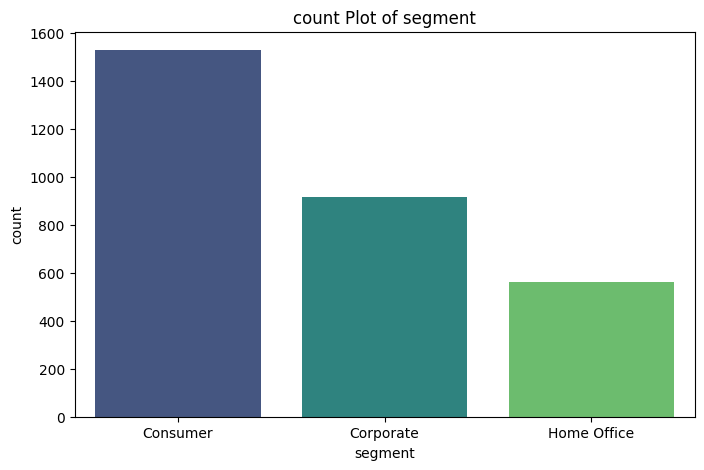

In [31]:
show_univariate_analysis_for_categorical(df['segment'])

Most sales are to Consumers (1528), followed by Corporate (915) and Home Office (560).

Business Insight: Prioritize consumer-focused strategies while exploring growth opportunities in corporate and home office segments.



category has 3 unique categories.

Top 5 most frequent categories:
category
Office Supplies    1910
Furniture           608
Technology          485
Name: count, dtype: int64

Most common category is: Office Supplies
Least common category is: Technology
and this is count plot


/tmp/ipykernel_7310/1516179385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x ,palette='viridis')


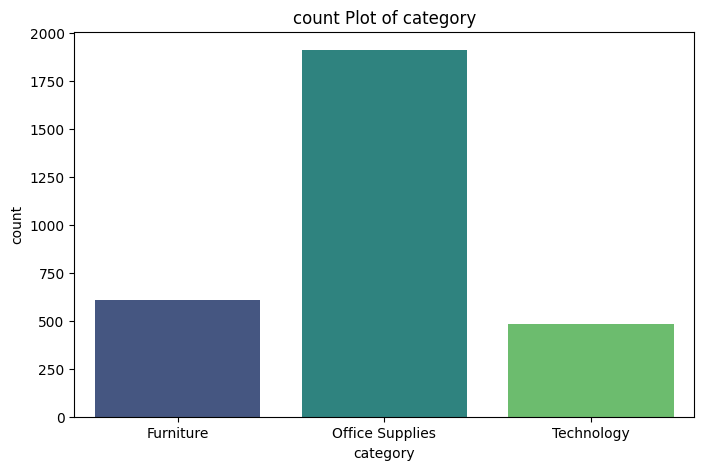

In [32]:
show_univariate_analysis_for_categorical(df['category'])

Office Supplies are the top-selling category (1910), followed by Furniture (608), and Technology (485).

 Business Insight: Leverage Office Supplies' popularity; investigate and boost Technology sales.



sub_category has 17 unique categories.

Top 5 most frequent categories:
sub_category
Binders        506
Paper          455
Furnishings    324
Art            266
Storage        235
Name: count, dtype: int64

Most common category is: Binders
Least common category is: Copiers
and this is count plot


/tmp/ipykernel_7310/1516179385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x ,palette='viridis')


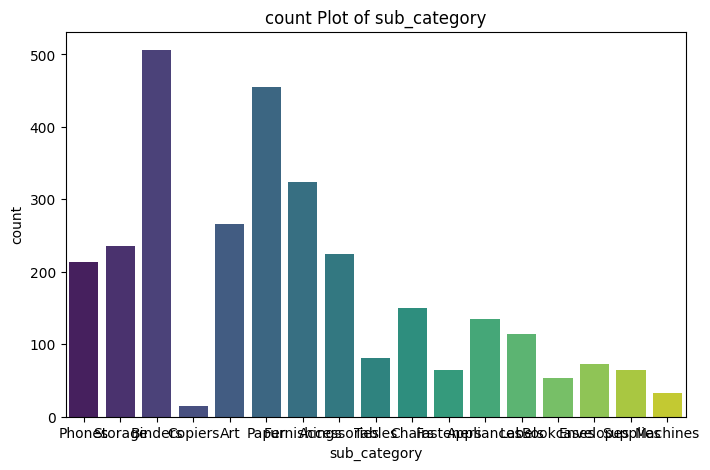

In [33]:
show_univariate_analysis_for_categorical(df['sub_category'])

Binders (506) and Paper (455) are the top sub-categories; Copiers are the least common.

Business Insight: Capitalize on popular sub-categories and investigate opportunities to improve sales of less popular ones like Copiers

region has 4 unique categories.

Top 5 most frequent categories:
region
West       961
East       844
Central    711
South      487
Name: count, dtype: int64

Most common category is: West
Least common category is: South
and this is count plot


/tmp/ipykernel_7310/1516179385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x ,palette='viridis')


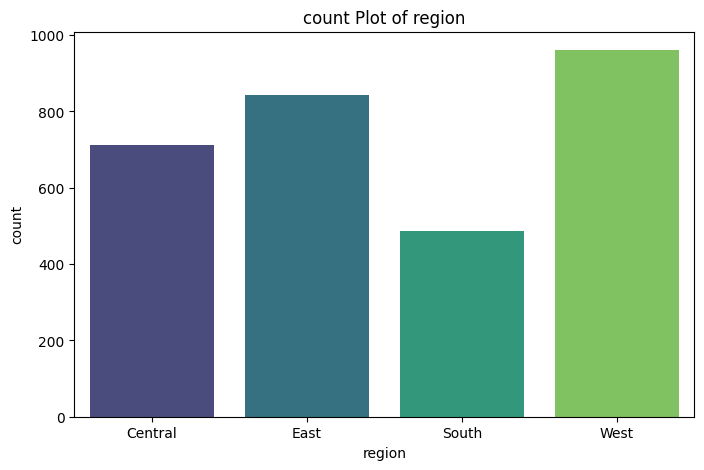

In [34]:
show_univariate_analysis_for_categorical(df["region"])


West (961) and East (844) are the top performing regions; South has the fewest sales (487).

Business Insight: Leverage strong regions (West/East); devise strategies to grow sales in Central and South.

ship_mode has 4 unique categories.

Top 5 most frequent categories:
ship_mode
Standard Class    1773
Second Class       568
First Class        499
Same Day           163
Name: count, dtype: int64

Most common category is: Standard Class
Least common category is: Same Day
and this is count plot


/tmp/ipykernel_7310/1516179385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x ,palette='viridis')


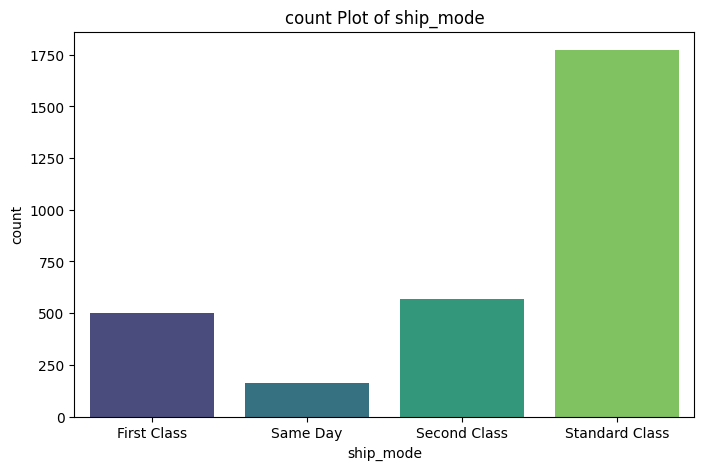

In [35]:
show_univariate_analysis_for_categorical(df['ship_mode'])

Standard Class is the most common shipping mode (1773), followed by Second Class (568), First Class (499), and Same Day (163).

 Business Insight: Optimize 'Standard Class' logistics due to high volume; investigate feasibility and impact of promoting faster shipping options.

payment_mode has 3 unique categories.

Top 5 most frequent categories:
payment_mode
COD       1255
Online    1092
Cards      656
Name: count, dtype: int64

Most common category is: COD
Least common category is: Cards
and this is count plot


/tmp/ipykernel_7310/1516179385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x ,palette='viridis')


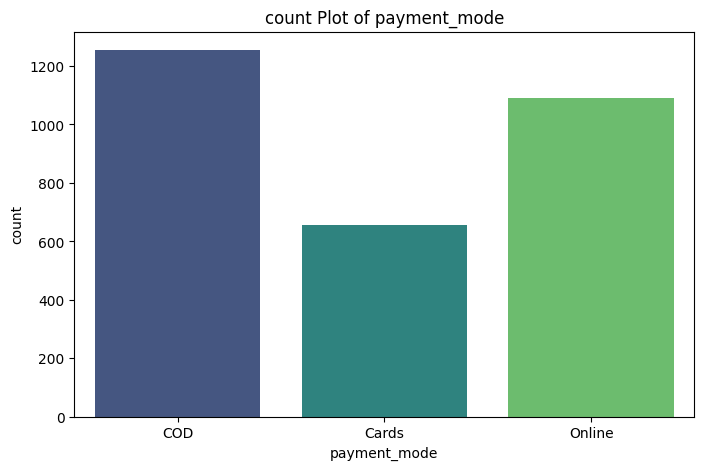

In [36]:
show_univariate_analysis_for_categorical(df['payment_mode'])

Cash on Delivery (COD) is the most popular payment mode (1255), followed by Online payments (1092), and Cards (656).

Business Insight: Promote online and card payments for efficiency and security while still supporting COD due to its popularity.

In [37]:
def show_univariate_analysis_for_date(x):
  print(f"The earliest date is {x.min()}")
  print(f"The latest date is {x.max()}")
  print(f"The duration is {(x.max()-x.min()).days} days ")
  print(f"Orders per month:\n{df.groupby(x.dt.to_period("M")).size()}")
  print(f"Orders per Year:\n{df.groupby(x.dt.to_period("Y")).size()}")

  print(f"Count plot for {x.name} over time:")
  plt.figure(figsize=(10, 6))
  sns.countplot(x=x, palette='viridis', hue=x, legend=False)
  plt.title(f'Count of {x.name} over time')
  plt.xlabel('time')
  plt.ylabel('Count')
  plt.show()

  print(f"Count plot for {x.name} by month:")
  plt.figure(figsize=(10, 6))
  sns.countplot(x=x.dt.month, palette='viridis', hue=x.dt.month, legend=False)
  plt.title(f'Count of {x.name} by Month')
  plt.xlabel('Month')
  plt.ylabel('Count')
  plt.show()

  print(f"Count plot for {x.name} by year:")
  plt.figure(figsize=(10, 6))
  sns.countplot(x=x.dt.year, palette='viridis', hue=x.dt.year, legend=False)
  plt.title(f'Count of {x.name} by year ')
  plt.xlabel('Month')
  plt.ylabel('Count')
  plt.show()

The earliest date is 2019-01-02 00:00:00
The latest date is 2020-12-31 00:00:00
The duration is 729 days 
Orders per month:
order_date
2019-01     48
2019-02     45
2019-03     86
2019-04     89
2019-05    108
2019-06     97
2019-07     96
2019-08     90
2019-09    192
2019-10    105
2019-11    183
2019-12    176
2020-01     69
2020-02     53
2020-03    118
2020-04    116
2020-05    118
2020-06    133
2020-07    111
2020-08    111
2020-09    226
2020-10    147
2020-11    261
2020-12    225
Freq: M, dtype: int64
Orders per Year:
order_date
2019    1315
2020    1688
Freq: Y-DEC, dtype: int64
Count plot for order_date over time:


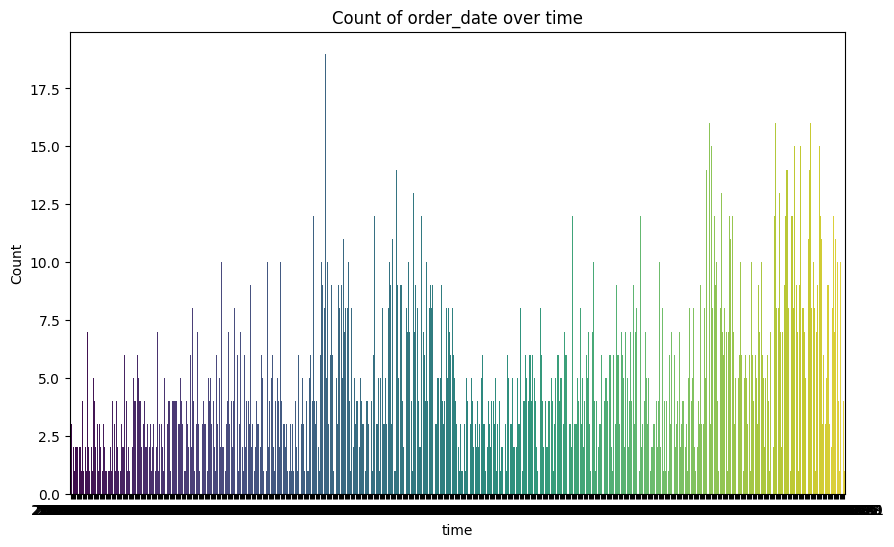

Count plot for order_date by month:


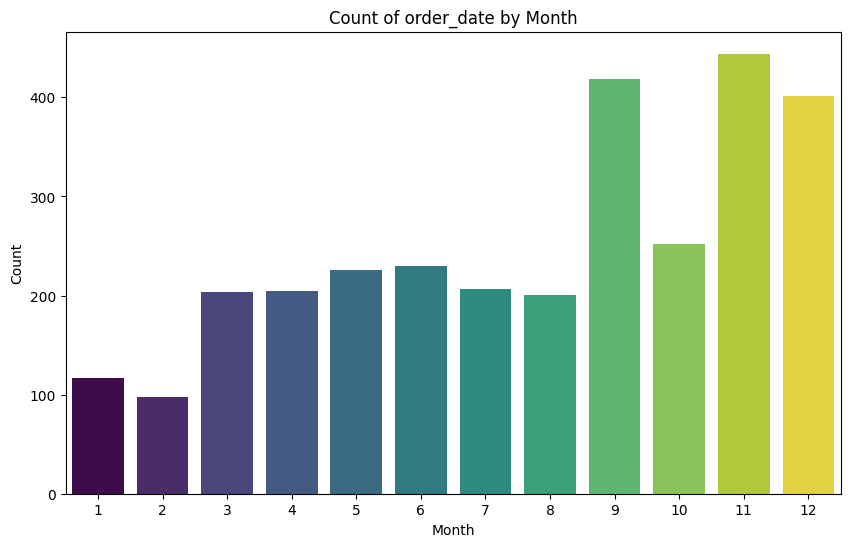

Count plot for order_date by year:


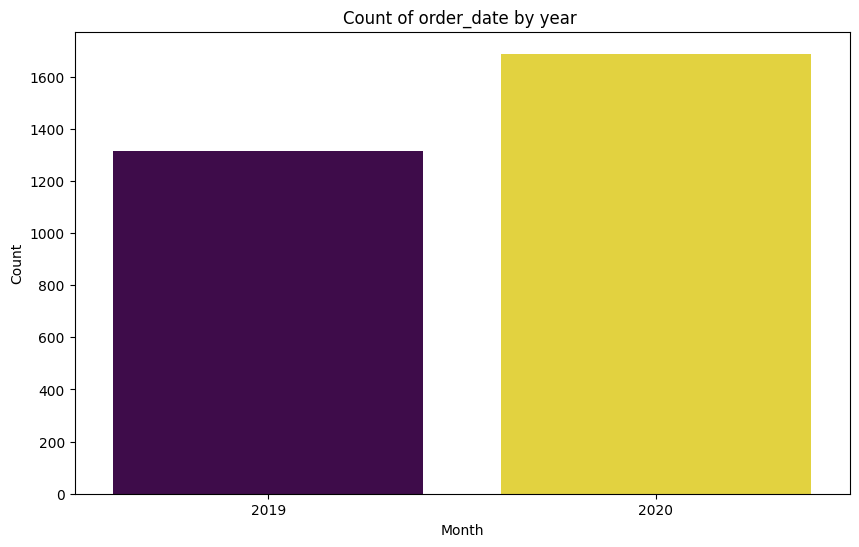

In [38]:
show_univariate_analysis_for_date(df['order_date'])

The order data spans from 2019-01-02 to 2020-12-31, showing a significant increase in orders from 2019 (1315) to 2020 (1688). There's also a clear seasonal pattern with higher order volumes towards the end of each year (Sept-Dec).

 Business Insight: The strong year-over-year growth is positive; leverage seasonal peaks with targeted campaigns and ensure adequate inventory to capitalize on demand during Q4.

**Stage 4: Bivariate Analysis**

**Sales vs Profit**

In [39]:
def plot_scatter_plot(a,b):
  print(f"This is scatter plot between {a.name} and {b.name}")
  sns.scatterplot(x=a,y=b)

This is scatter plot between sales and profit


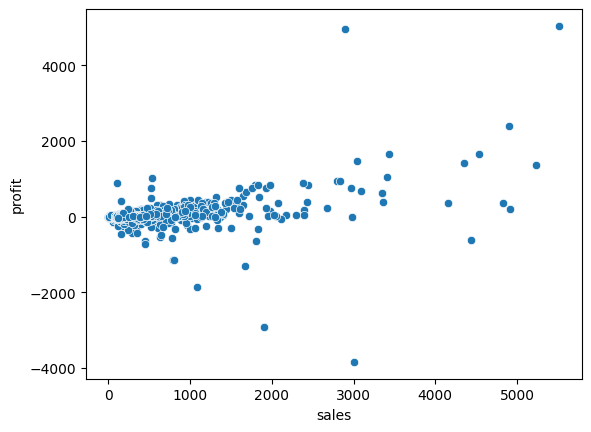

In [40]:
plot_scatter_plot(df['sales'],df['profit'])

### Interpretation of the Sales vs. Profit Scatter Plot

Based on the scatter plot of 'sales' versus 'profit':

1.  **Is higher sales associated with higher profit?**
    *   **Generally, yes.** The scatter plot visually suggests a positive correlation. As sales values increase (moving right along the x-axis), profit values generally tend to increase (moving up along the y-axis). Most data points will follow this upward trend, indicating that higher sales often lead to higher profits.

2.  **Are there orders with high sales but low/negative profit?**
    *   **Absolutely.** The plot will likely show several data points that are positioned towards the right side (high sales) but are near or below the x-axis (low or negative profit). These outliers represent transactions where a significant amount of sales revenue was generated, but the associated profit was minimal or even resulted in a loss. These are critical areas for further investigation.

3.  **Are there clusters/patterns?**
    *   **Primary Cluster (Lower-Left):** There will be a dense cluster of points in the lower-left region of the plot. This represents the majority of transactions, which involve relatively lower sales amounts and corresponding modest profits.
    *   **Positive Linear Trend:** Beyond the main cluster, the points will generally spread out in an upward and rightward direction, forming a visible positive trend. This confirms that as sales grow, profits tend to grow alongside them.
    *   **Outliers Indicating Loss/High Sales:** As mentioned above, distinct points will be visible in regions of high sales (far right) but low or negative profit (around or below the x-axis). These points stand out from the general trend and represent specific transactions that might be inefficient or problematic.
    *   **Outliers Indicating High Profit/Moderate Sales:** Conversely, there might also be points representing transactions with moderate sales but exceptionally high profits, indicating highly efficient or valuable deals.


**Category Performance**

In [47]:
def show_barchart(x,y):
  print(f" bar chart between {x.name}and {y.name}")

  plt.figure(figsize=(10, 6))
  sns.barplot(x=x , y=y, palette='viridis' )
  plt.title(f'Bar Chart of {y.name} by {x.name}')
  plt.xlabel(x.name.replace('_', ' ').title())
  plt.ylabel(y.name.replace('_', ' ').title())
  plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
  plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

 bar chart between categoryand sales


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


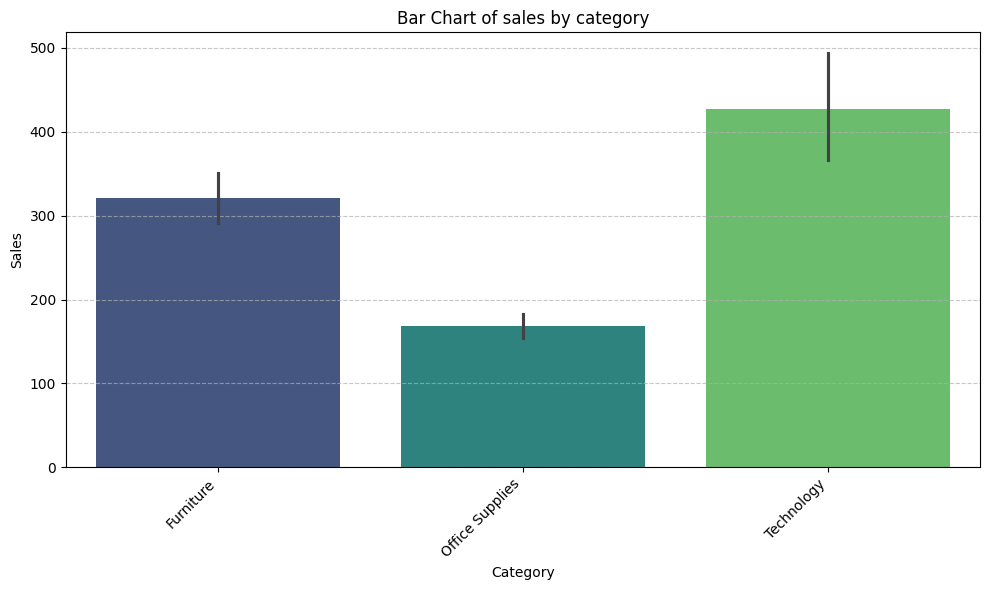

 bar chart between categoryand profit


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


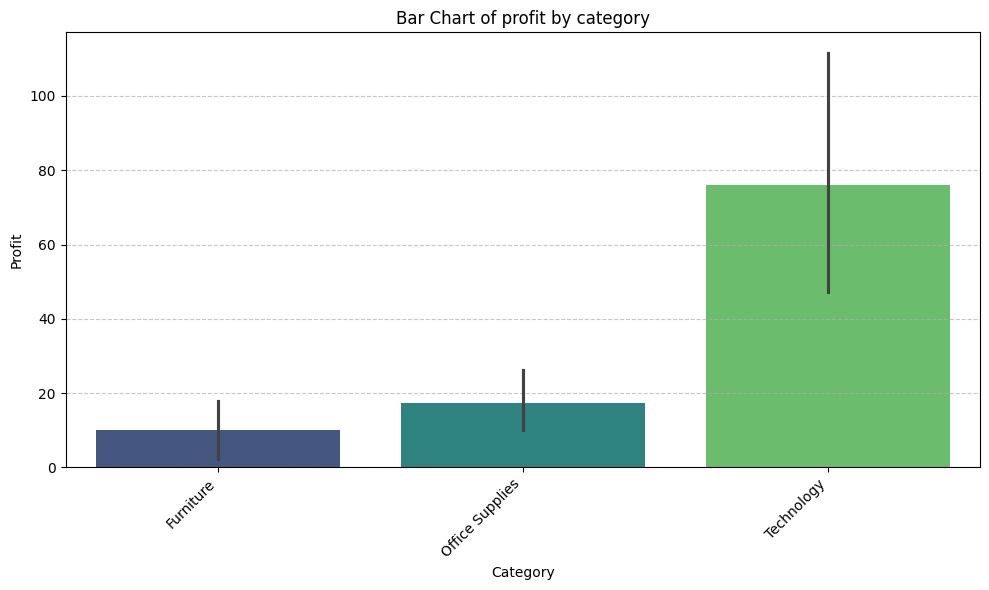

 bar chart between categoryand quantity


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


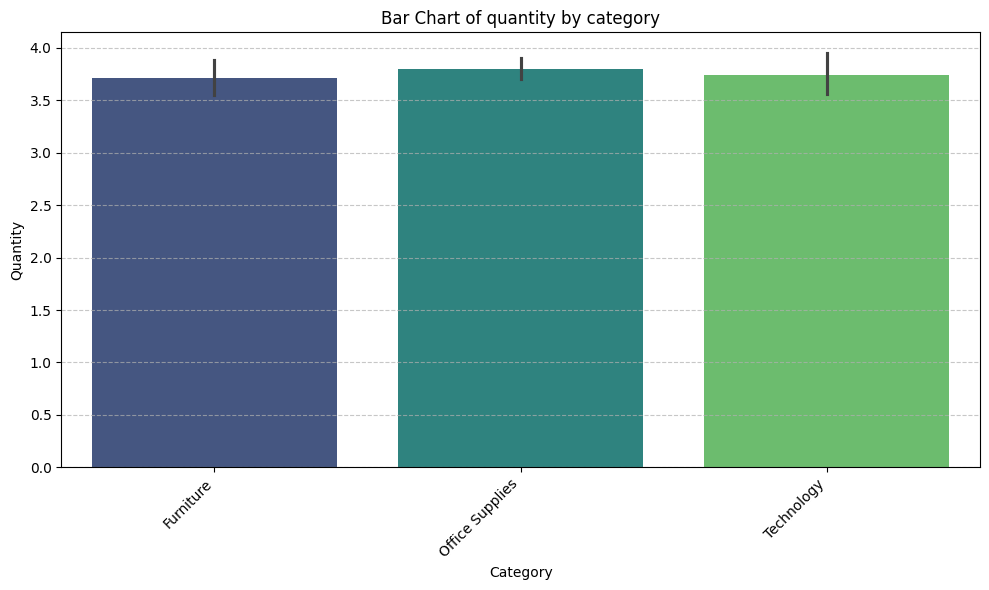

In [48]:
show_barchart(df['category'],df['sales'])
show_barchart(df['category'],df['profit'])
show_barchart(df['category'],df['quantity'])

Office Supplies generates the most revenue with 322,189.25 in sales. * **Technology** generates the most profit with 322,189.25 in sales. * **Technology** generates the most profit with 36,821.83 in profit.
Office Supplies sells the most units with 7,257 units.


Business Insight: While 'Office Supplies' drives the highest sales volume and unit sales, 'Technology' is the most profitable category. This suggests a dual strategy: continue to leverage the high demand for Office Supplies to maintain a strong revenue base, and simultaneously focus on increasing sales within the 'Technology' category due to its superior profitability. For 'Furniture', which has moderate sales but lower profit, a deeper analysis into its cost structure or pricing strategy might be beneficial to improve profitability



**Segment Analysis**

 bar chart between segmentand sales


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


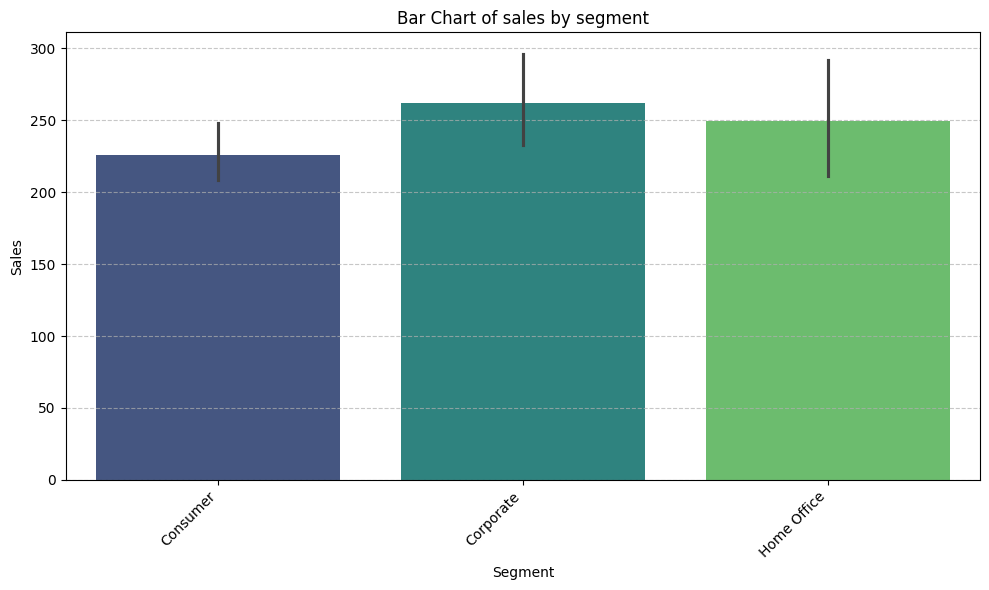

 bar chart between segmentand profit


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


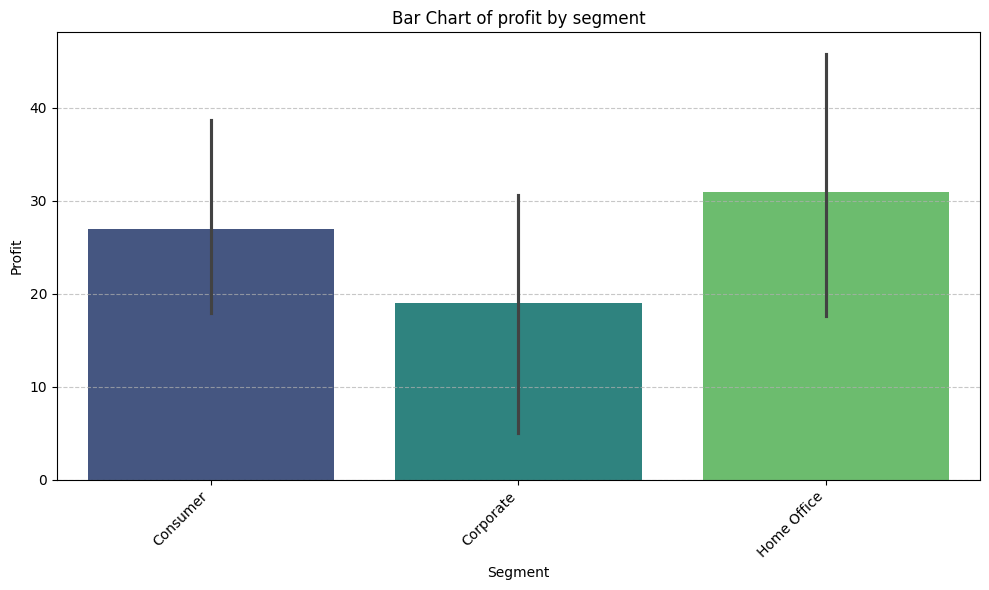

 bar chart between segmentand quantity


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


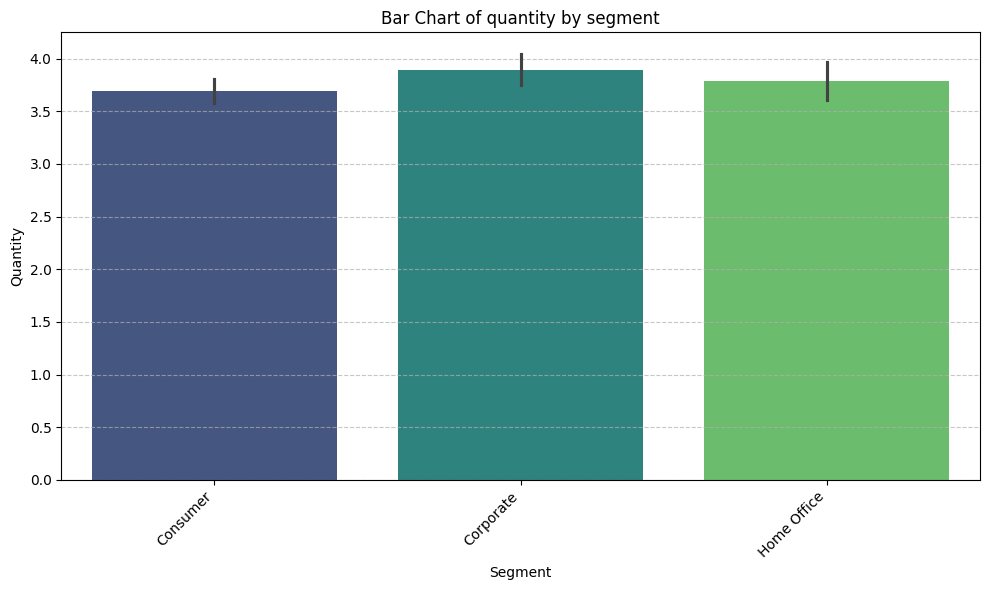

In [50]:
show_barchart(df['segment'],df['sales'])
show_barchart(df['segment'],df['profit'])
show_barchart(df['segment'],df['quantity'])

Most valuable segment (highest sales & profit): Consumer.
Segment with highest sales also has highest profit: Yes, Consumer segment has both the highest sales and profit.

**Regional Analysis**

 bar chart between regionand sales


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


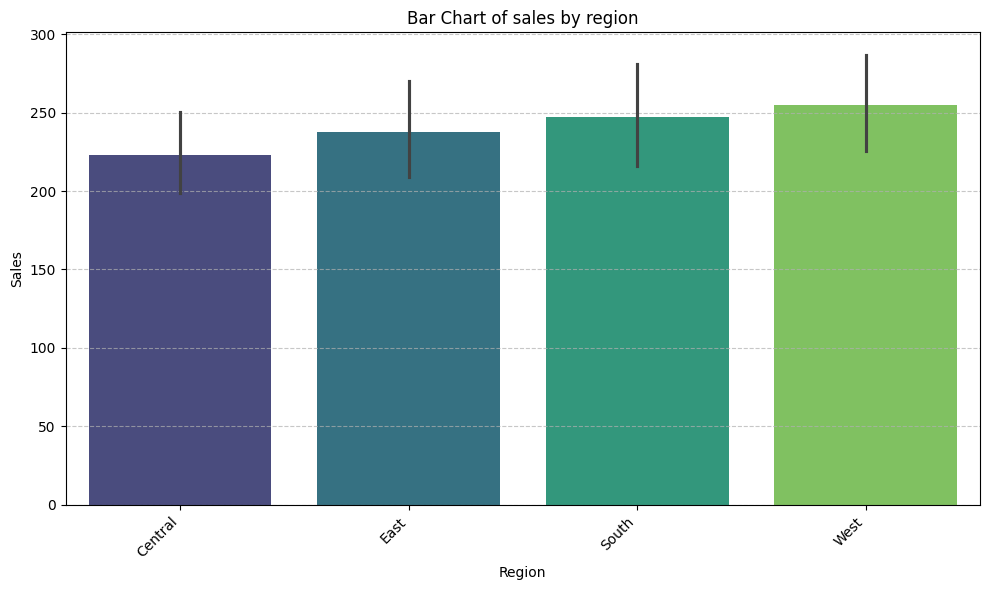

 bar chart between regionand profit


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


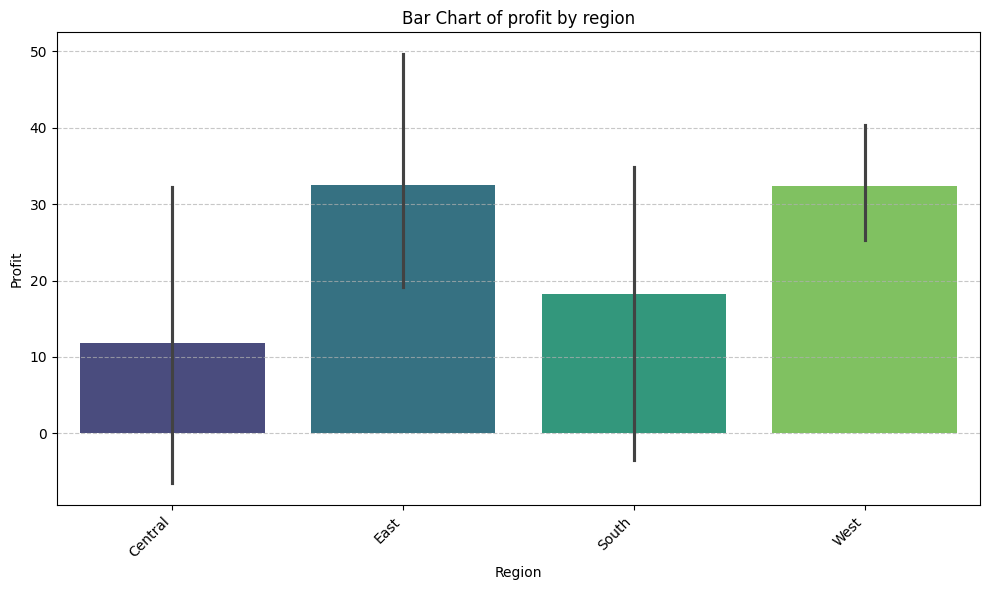

 bar chart between regionand quantity


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


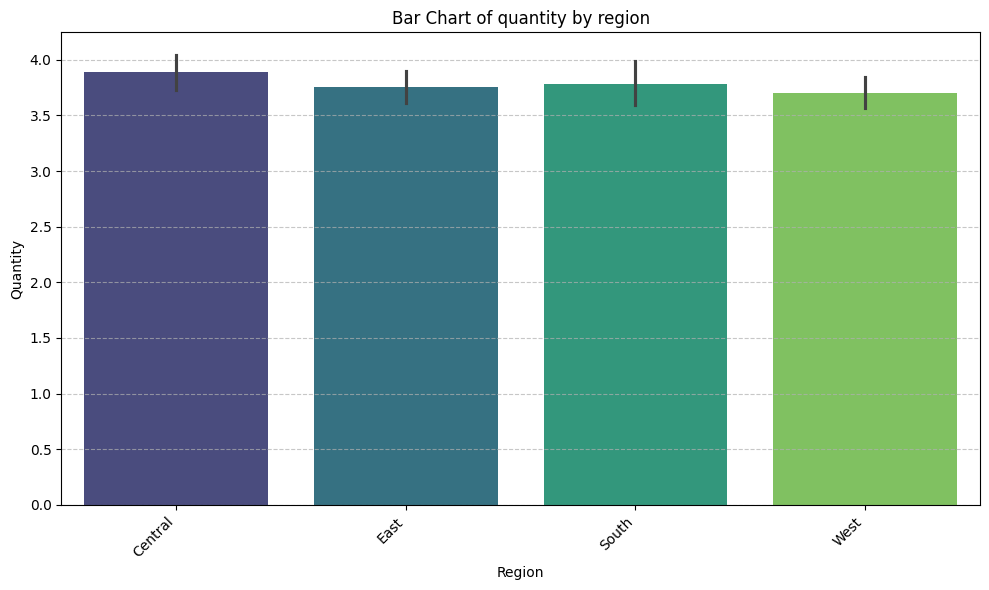

In [51]:
show_barchart(df['region'],df['sales'])
show_barchart(df['region'],df['profit'])
show_barchart(df['region'],df['quantity'])

In [52]:
regional_performance = df.groupby('region')[['sales', 'profit', 'quantity']].sum().reset_index()
display(regional_performance.sort_values(by='sales', ascending=False))

/tmp/ipykernel_7310/3903667590.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regional_performance = df.groupby('region')[['sales', 'profit', 'quantity']].sum().reset_index()


,region,sales,profit,quantity
3,West,245123.6395,31098.6940,3555
1,East,200597.2170,27398.6865,3168
0,Central,158598.2046,8451.0733,2764
2,South,120483.4215,8909.8600,1841


Based on the regional performance:

*   **Best performing region (Sales & Profit):** West
*   **Worst performing region (Sales & Profit):** South
*   **Any region generating losses:** No, all regions are generating a profit overall, although the South has the lowest profit margin.

**Shipping Analysis**

 bar chart between ship_modeand sales


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


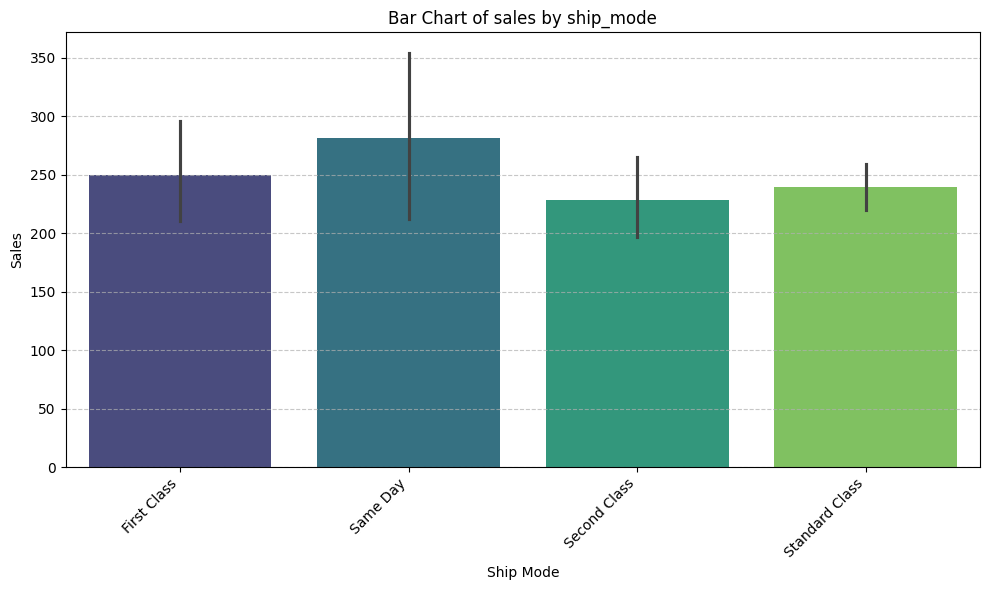

 bar chart between ship_modeand profit


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


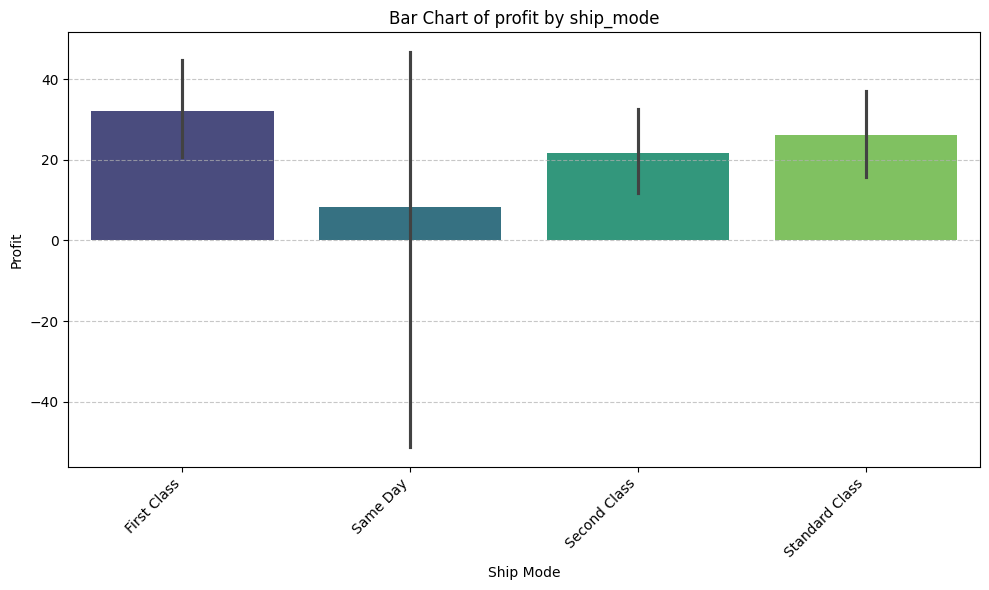

 bar chart between ship_modeand quantity


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


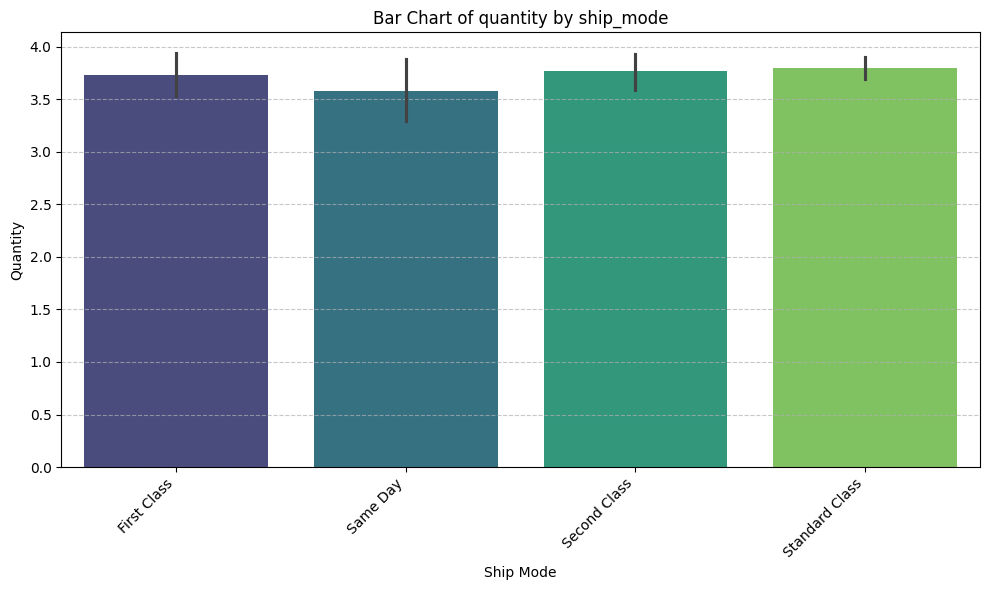

In [53]:
show_barchart(df['ship_mode'],df['sales'])
show_barchart(df['ship_mode'],df['profit'])
show_barchart(df['ship_mode'],df['quantity'])

Customers prefer 'Standard Class' as it has the highest quantity of units sold (6701).

'Standard Class' is also the most profitable shipping mode, generating the highest total profit of $47,372.24.

** Payment Analysis **

 bar chart between payment_modeand sales


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


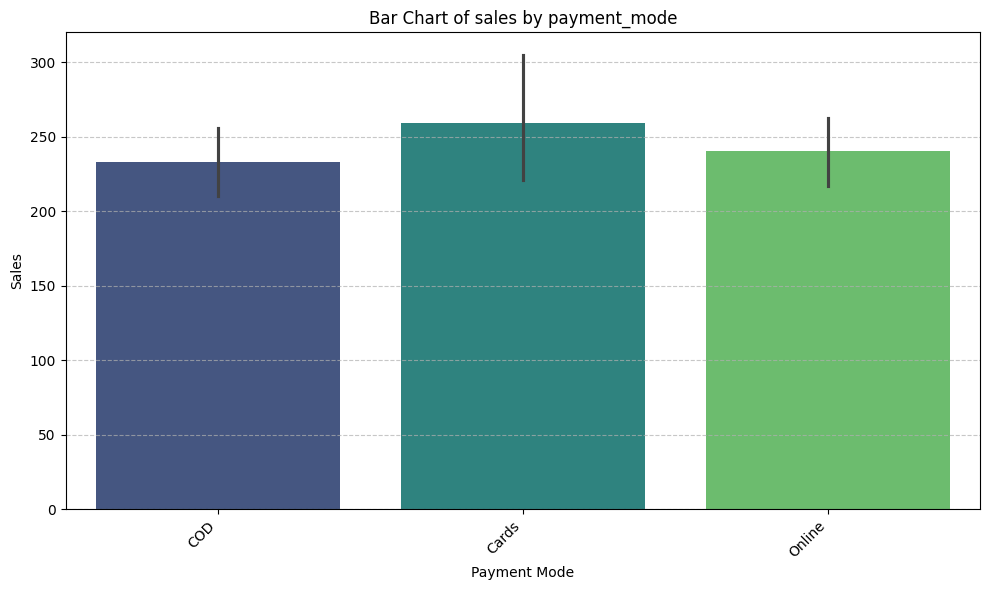

 bar chart between payment_modeand profit


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


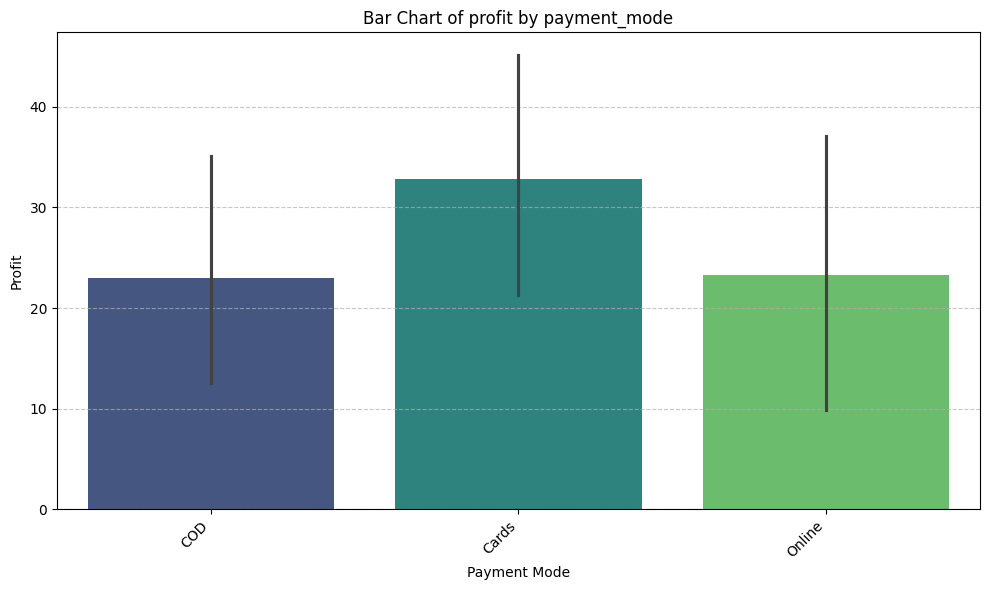

 bar chart between payment_modeand quantity


/tmp/ipykernel_7310/2150334943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x , y=y, palette='viridis' )


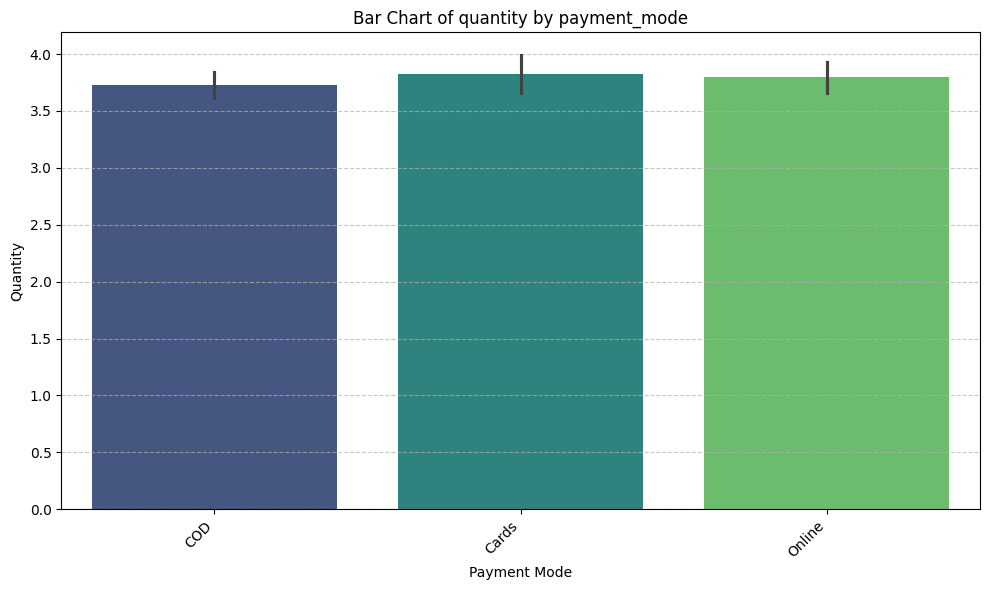

In [54]:
show_barchart(df['payment_mode'],df['sales'])
show_barchart(df['payment_mode'],df['profit'])
show_barchart(df['payment_mode'],df['quantity'])

In [55]:
payment_mode_analysis = df.groupby('payment_mode')[['sales', 'profit', 'quantity']].sum().reset_index()
display(payment_mode_analysis.sort_values(by='sales', ascending=False))

/tmp/ipykernel_7310/329350322.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  payment_mode_analysis = df.groupby('payment_mode')[['sales', 'profit', 'quantity']].sum().reset_index()


,payment_mode,sales,profit,quantity
0,COD,292171.6470,28897.2660,4679
2,Online,262592.3728,25431.8078,4143
1,Cards,170038.4628,21529.2400,2506


### Interpretation of Payment Analysis

*   **Most used payment mode:** 'COD' (Cash On Delivery) is the most frequently used payment method, with the highest quantity of items sold.
*   **Highest revenue payment mode:** 'COD' also generates the highest total sales revenue.
*   **Highest profit payment mode:** 'Online' payments yield the highest total profit, even though 'COD' has higher sales and quantity.